# AI LÀ AI

Notebook baseline tạo trực tiếp `submission.zip` cho tập kiểm tra.

## 1. Cấu hình

In [ ]:
import os

# Phải đặt trước khi torch khởi tạo CUDA.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import random
import time
import zipfile
import matplotlib.pyplot as plt

import numpy as np
import torchvision as tv
import pandas as pd
import torch

from PIL import Image, ImageOps
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as tf

from facenet_pytorch import MTCNN

DATA_ROOT = Path('../data/')
test = 'public_test'        # đổi thành 'private_test' ở giai đoạn kiểm tra bí mật

EPOCHS = 5
BATCH_SIZE = 64
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Cố định kết quả giữa các lần chạy: cùng seed -> cùng file nộp.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[cấu hình] split={test} | epochs={EPOCHS} | batch={BATCH_SIZE} | seed={SEED}')
print(f'[cấu hình] thiết bị: {DEVICE}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))

[cấu hình] split=public_test | epochs=5 | batch=64 | seed=42
[cấu hình] thiết bị: cpu


c:\Users\Admin\miniconda3\envs\deepfake-detection\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load data


In [4]:
DATA_ROOT = Path('../data/')
if not (DATA_ROOT / 'train' / 'manifest.csv').is_file():
    DATA_ROOT = Path.cwd() / 'data'

manifest_path = DATA_ROOT / 'train' / 'manifest.csv'
manifest = pd.read_csv(manifest_path)
data = manifest.copy()
data['image_path'] = data['path'].map(lambda path: DATA_ROOT / 'train' / path)

missing_images = data.loc[~data['image_path'].map(Path.is_file), 'image_path']
if not missing_images.empty:
    raise FileNotFoundError(
        f'Không tìm thấy {len(missing_images)} ảnh, ví dụ: {missing_images.iloc[0]}'
    )

def inspect_image(image_path):
    try:
        with Image.open(image_path) as image:
            image.load()
            width, height = image.size
            return {
                'width': width,
                'height': height,
                'aspect_ratio': width / height,
                'mode': image.mode,
                'format': image.format,
                'size_kb': image_path.stat().st_size / 1024,
                'image_error': None,
            }
    except Exception as error:
        return {
            'width': None,
            'height': None,
            'aspect_ratio': None,
            'mode': None,
            'format': None,
            'size_kb': image_path.stat().st_size / 1024,
            'image_error': str(error),
        }

image_info = pd.DataFrame(data['image_path'].map(inspect_image).tolist(), index=data.index)
data = pd.concat([data, image_info], axis=1)

print(f'Đã nạp metadata {len(data):,} ảnh từ {manifest_path.resolve()}')
print(f'Ảnh lỗi/không đọc được: {data["image_error"].notna().sum()}')
display(data.head())

Đã nạp metadata 2,000 ảnh từ D:\PROJECT-data-src\aio-conquer\deepfake-detection\data\train\manifest.csv
Ảnh lỗi/không đọc được: 0


,label,class_name,path,image_path,width,height,aspect_ratio,mode,format,size_kb,image_error
0,0,Real,images/00079.jpg,..\data\train\images\00079.jpg,512,512,1.0,RGB,JPEG,79.788086,None
1,0,Real,images/00586.jpg,..\data\train\images\00586.jpg,512,512,1.0,RGB,JPEG,64.904297,None
2,0,Real,images/01426.jpg,..\data\train\images\01426.jpg,512,512,1.0,RGB,JPEG,75.315430,None
3,0,Real,images/01562.jpg,..\data\train\images\01562.jpg,512,512,1.0,RGB,JPEG,85.682617,None
4,0,Real,images/00295.jpg,..\data\train\images\00295.jpg,512,512,1.0,RGB,JPEG,81.657227,None


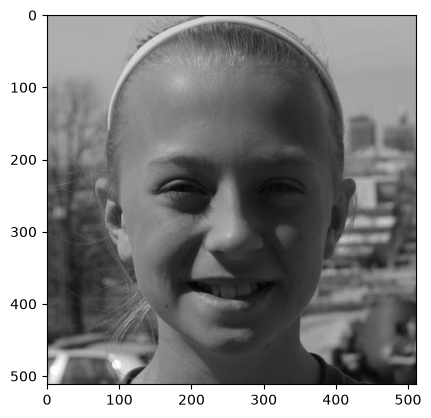

In [40]:

path = DATA_ROOT / 'train' / 'images' / '00005.jpg'
img = tv.io.read_image(path, mode = tv.io.ImageReadMode.RGB)
plt.imshow(img.permute(1,2,0))

In [ ]:
from sklearn.model_selection import StratifiedKFold


## Size image
+ Kiểm tra xem ảnh giữa class 0-1 có khác nhau về size nhiều không


Thống kê dung lượng file ảnh theo class (KB):


,,image_count,mean_kb,median_kb,std_kb,min_kb,max_kb,q25_kb,q75_kb
label,class_name,,,,,,,,
0,Real,1000,67.46,66.12,14.02,36.72,118.62,56.57,77.06
1,Fake,1000,57.33,56.34,13.91,28.00,111.08,47.43,66.69


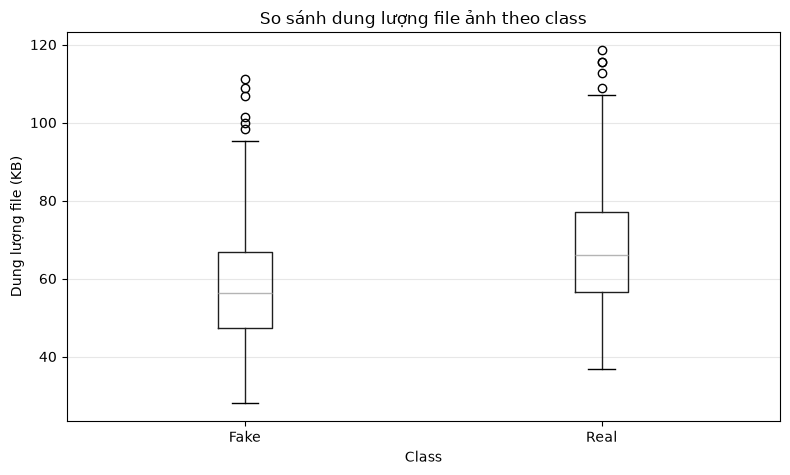

In [74]:
valid_file_sizes = data.dropna(subset=['size_kb']).copy()

file_size_summary = valid_file_sizes.groupby(['label', 'class_name'])['size_kb'].agg(
    image_count='count',
    mean_kb='mean',
    median_kb='median',
    std_kb='std',
    min_kb='min',
    max_kb='max',
    q25_kb=lambda values: values.quantile(0.25),
    q75_kb=lambda values: values.quantile(0.75),
)
print('Thống kê dung lượng file ảnh theo class (KB):')
display(file_size_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
valid_file_sizes.boxplot(
    column='size_kb',
    by='class_name',
    ax=ax,
    grid=False,
    showfliers=True,
)
ax.set_title('So sánh dung lượng file ảnh theo class')
ax.set_xlabel('Class')
ax.set_ylabel('Dung lượng file (KB)')
fig.suptitle('')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Preprocessing

## Augmumentation
+ Flip
+ Rotate nhẹ

## Crop

torch.Size([3, 400, 350])


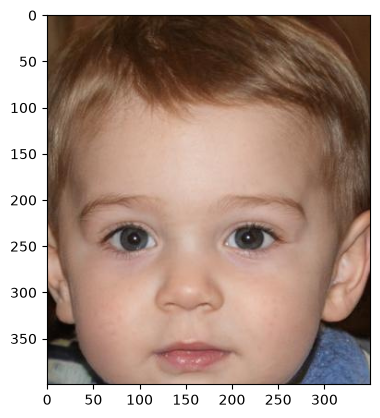

In [17]:
img1 = tf.functional.crop(img, 0, 100, height=400,width=350)
print(img1.shape)
plt.imshow(img1.permute(1,2,0))

## Face detection
+ Liệu có ảnh nào ko detect được mặt không?
+ Phân bố kích thước khuôn mặt 

Số khuôn mặt phát hiện được: 1


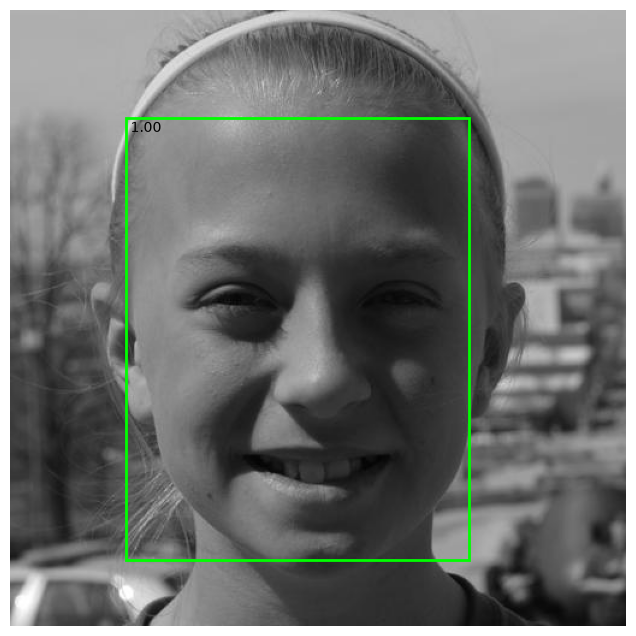

In [69]:
# img là tensor RGB có dạng [C, H, W]
image_rgb = img.permute(1, 2, 0)
face_detector = MTCNN(keep_all=True, device=DEVICE,min_face_size=100)
boxes, probabilities = face_detector.detect(image_rgb)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_rgb)

if boxes is None:
    print('Không phát hiện được khuôn mặt trong ảnh.')
else:
    for box, probability in zip(boxes, probabilities):
        xmin, ymin, xmax, ymax = box
        ax.add_patch(plt.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            fill=False, edgecolor='lime', linewidth=2
        ))
        ax.text(
            x1, y1, f'{probability:.2f}', color='black',
        )
        plt.plot(x1,y1)
    print(f'Số khuôn mặt phát hiện được: {len(boxes)}')

ax.axis('off')
plt.show()

2
2
Đã detect 100/2000 ảnh
2
Đã detect 200/2000 ảnh
3
2
2
Đã detect 300/2000 ảnh
2
Đã detect 400/2000 ảnh
2
2
Đã detect 500/2000 ảnh
2
Đã detect 600/2000 ảnh
2
2
2
2
Đã detect 700/2000 ảnh
2
Đã detect 800/2000 ảnh
2
Đã detect 900/2000 ảnh
2
Đã detect 1000/2000 ảnh
Đã detect 1100/2000 ảnh
2
Đã detect 1200/2000 ảnh
2
Đã detect 1300/2000 ảnh
Đã detect 1400/2000 ảnh
2
2
2
Đã detect 1500/2000 ảnh
2
2
Đã detect 1600/2000 ảnh
Đã detect 1700/2000 ảnh
2
2
2
Đã detect 1800/2000 ảnh
Đã detect 1900/2000 ảnh
Đã detect 2000/2000 ảnh
Tổng số bounding box: 2018
Số ảnh không detect được mặt: 10
Các path không detect được mặt:
['..\\data\\train\\images\\00012.jpg', '..\\data\\train\\images\\00601.jpg', '..\\data\\train\\images\\01704.jpg', '..\\data\\train\\images\\00710.jpg', '..\\data\\train\\images\\00118.jpg', '..\\data\\train\\images\\00956.jpg', '..\\data\\train\\images\\00971.jpg', '..\\data\\train\\images\\01438.jpg', '..\\data\\train\\images\\00783.jpg', '..\\data\\train\\images\\00195.jpg']


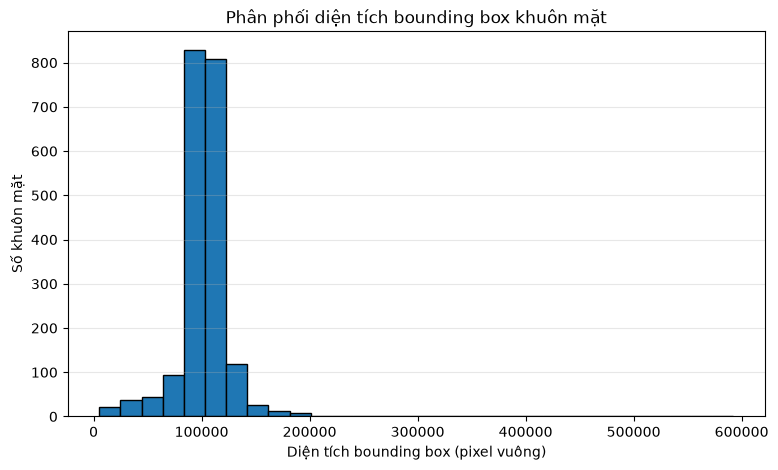

In [70]:
face_box_records = []
no_face_paths = []
more_than_one_face_paths  = []

image_paths = data['image_path'].tolist()
for image_index, image_path in enumerate(image_paths, start=1):
    img_run = tv.io.read_image(str(image_path),mode=tv.io.ImageReadMode.RGB)
    image_rgb_run = img_run.permute(1, 2, 0)
    boxes, probabilities = face_detector.detect(image_rgb_run)

    if boxes is None or len(boxes) == 0:
        no_face_paths.append(str(image_path))
    else:
        if len(boxes) > 1 :
            print(len(boxes))
            more_than_one_face_paths.append(image_path)
        for face_index, box in enumerate(boxes, start=1):
            xmin, ymin, xmax, ymax = box
            box_width = max(0.0, float(xmax - xmin))
            box_height = max(0.0, float(ymax - ymin))
            face_box_records.append({
                'image_path': str(image_path),
                'face_index': face_index,
                'box_width': box_width,
                'box_height': box_height,
                'box_area': box_width * box_height,
                'probability': float(probabilities[face_index - 1]),
            })

    if image_index % 100 == 0 or image_index == len(image_paths):
        print(f'Đã detect {image_index}/{len(image_paths)} ảnh')

face_boxes_df = pd.DataFrame(face_box_records)
face_areas = face_boxes_df['box_area'].tolist()

print(f'Tổng số bounding box: {len(face_areas)}')
print(f'Số ảnh không detect được mặt: {len(no_face_paths)}')
print('Các path không detect được mặt:')
print(no_face_paths)

if face_areas:
    plt.figure(figsize=(9, 5))
    plt.hist(face_areas, bins=30, edgecolor='black')
    plt.xlabel('Diện tích bounding box (pixel vuông)')
    plt.ylabel('Số khuôn mặt')
    plt.title('Phân phối diện tích bounding box khuôn mặt')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print('Không có bounding box để vẽ histogram.')

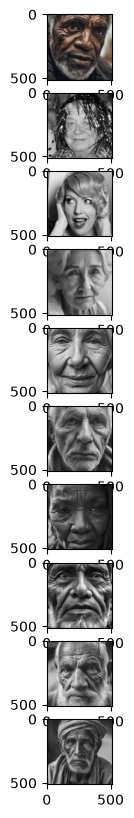

In [71]:
plt.figure(figsize=(10,10))
for i, path in enumerate(no_face_paths):
    img_run = tv.io.read_image(str(path),mode=tv.io.ImageReadMode.RGB)
    plt.subplot(len(no_face_paths),1,i+1)
    plt.imshow(img_run.permute(1,2,0))

số ảnh có nhiều khuôn mặt 27


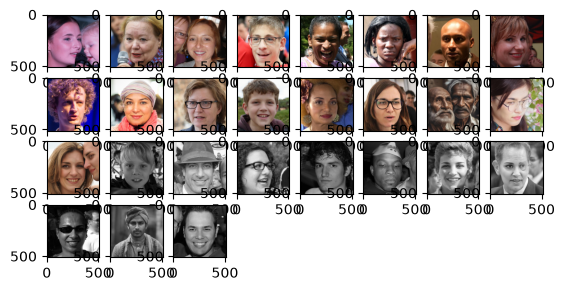

In [72]:
size_more_than_one_face = len(more_than_one_face_paths)
print("số ảnh có nhiều khuôn mặt", size_more_than_one_face)
for i, path in enumerate(more_than_one_face_paths):
    img_run = tv.io.read_image(str(path),mode=tv.io.ImageReadMode.RGB)
    plt.subplot(6,8,i+1)
    plt.imshow(img_run.permute(1,2,0))

## Normalize

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1029.2142].


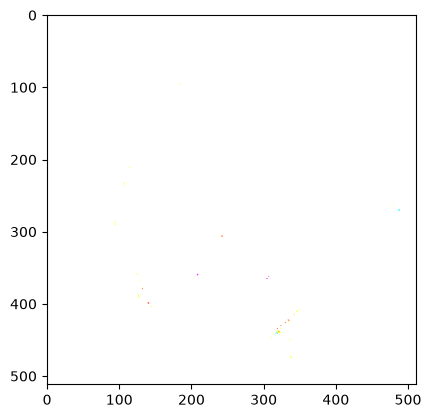

In [35]:

img2 = tf.functional.normalize(
    img.float(),
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)
plt.imshow(img2.permute(1, 2, 0))